# PHÂN TÍCH HIỆN TƯỢNG NẮNG NÓNG VÀ DỰ BÁO NHIỆT ĐỘ

**Phạm vi:** Hà Nội, Đà Nẵng và TP.HCM.  
**Nguồn dữ liệu:** Open-Meteo, dữ liệu theo giờ.  
**Dữ liệu huấn luyện:** từ năm 2020 đến hết **31/05/2026**.  
**Quy ước:** ngày nắng nóng là ngày có nhiệt độ cao nhất **từ 35°C trở lên**.

## Các câu hỏi

### Phân tích dữ liệu
1. Thành phố nào có nhiệt độ trung bình cao nhất?
2. Nhiệt độ thay đổi như thế nào theo từng tháng?
3. Khung giờ nào trong ngày thường có nhiệt độ cao nhất?
4. Số ngày nắng nóng tại mỗi thành phố thay đổi như thế nào qua từng năm?
5. Đợt nắng nóng kéo dài nhất tại mỗi thành phố diễn ra khi nào và kéo dài bao nhiêu ngày?

### Dự báo tháng 7–12/2026
1. Nhiệt độ trung bình từng tháng tại ba thành phố được dự báo là bao nhiêu?
2. Số ngày nắng nóng từng tháng tại ba thành phố được dự báo là bao nhiêu?

## 1. Khai báo thư viện và thư mục

In [3]:
# Trong Python, dòng chú thích bắt đầu bằng dấu #, không dùng //.
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Hiển thị bảng và biểu đồ dễ quan sát hơn.
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 120)
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True

# Thư mục dữ liệu đầu vào, kết quả và biểu đồ.
DATA_DIR = Path("data")
IMAGE_DIR = Path("images")
DATA_DIR.mkdir(exist_ok=True)
IMAGE_DIR.mkdir(exist_ok=True)

## 2. Đọc và làm sạch dữ liệu

In [4]:
# Tên ba file phải đúng như cấu trúc dưới đây.
FILES = {
    "Hà Nội": DATA_DIR / "hanoi_heat_2020_2025.csv",
    "Đà Nẵng": DATA_DIR / "danang_heat_2020_2025.csv",
    "TP.HCM": DATA_DIR / "hcm_heat_2020_2025.csv",
}


def read_open_meteo(path, city):
    """Đọc một file Open-Meteo và chuẩn hóa tên cột."""
    if not path.exists():
        raise FileNotFoundError(f"Không tìm thấy file: {path}")

    # File Open-Meteo có vài dòng metadata trước dòng tiêu đề 'time,...'.
    with open(path, "r", encoding="utf-8-sig") as f:
        lines = f.readlines()

    header_rows = [i for i, line in enumerate(lines) if line.strip().lower().startswith("time,")]
    if not header_rows:
        raise ValueError(f"Không tìm thấy dòng tiêu đề 'time' trong file {path.name}")

    df = pd.read_csv(path, skiprows=header_rows[0])
    df.columns = [col.strip() for col in df.columns]

    # Đổi tên cột dài thành tên ngắn, dễ sử dụng trong code.
    df = df.rename(columns={
        "temperature_2m (°C)": "temperature",
        "cloud_cover (%)": "cloud_cover",
        "wind_speed_10m (km/h)": "wind_speed",
        "relative_humidity_2m (%)": "humidity",
        "apparent_temperature (°C)": "apparent_temperature",
        "precipitation (mm)": "precipitation",
    })

    required = [
        "time", "temperature", "cloud_cover", "wind_speed",
        "humidity", "apparent_temperature", "precipitation"
    ]
    missing = [col for col in required if col not in df.columns]
    if missing:
        raise ValueError(f"File {path.name} thiếu cột: {missing}")

    # Chuyển thời gian và các thuộc tính thời tiết về đúng kiểu dữ liệu.
    df = df[required].copy()
    df["time"] = pd.to_datetime(df["time"], errors="coerce")
    for col in required[1:]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df["city"] = city
    return df.dropna(subset=["time", "temperature"])


# Ghép dữ liệu của ba thành phố.
hourly = pd.concat(
    [read_open_meteo(path, city) for city, path in FILES.items()],
    ignore_index=True
)

# Tháng 6/2026 chưa đầy đủ nên chỉ giữ dữ liệu đến hết ngày 31/05/2026.
hourly = hourly[hourly["time"] <= "2026-05-31 23:59:59"].copy()

# Tạo các thuộc tính thời gian phục vụ phân tích.
hourly["date"] = hourly["time"].dt.normalize()
hourly["year"] = hourly["time"].dt.year
hourly["month"] = hourly["time"].dt.month
hourly["hour"] = hourly["time"].dt.hour

print(f"Số dòng dữ liệu theo giờ: {len(hourly):,}")
print(f"Thời gian: {hourly['time'].min()} đến {hourly['time'].max()}")
display(hourly.groupby("city").size().rename("so_dong").to_frame())
display(hourly.head())

Số dòng dữ liệu theo giờ: 168,696
Thời gian: 2020-01-01 00:00:00 đến 2026-05-31 23:00:00


,so_dong
city,
Hà Nội,56232
TP.HCM,56232
Đà Nẵng,56232


,time,temperature,cloud_cover,wind_speed,humidity,apparent_temperature,precipitation,city,date,year,month,hour
0,2020-01-01 00:00:00,19.5,100,3.3,93,22.1,0.5,Hà Nội,2020-01-01,2020,1,0
1,2020-01-01 01:00:00,19.4,100,3.7,94,21.9,0.3,Hà Nội,2020-01-01,2020,1,1
2,2020-01-01 02:00:00,19.2,100,3.3,94,21.7,0.1,Hà Nội,2020-01-01,2020,1,2
3,2020-01-01 03:00:00,19.1,100,2.8,95,21.7,0.2,Hà Nội,2020-01-01,2020,1,3
4,2020-01-01 04:00:00,18.9,100,4.8,95,21.2,0.1,Hà Nội,2020-01-01,2020,1,4


## 3. Tổng hợp dữ liệu theo ngày và theo tháng

In [5]:
# Tổng hợp dữ liệu theo ngày.
daily = (
    hourly.groupby(["city", "date"], as_index=False)
    .agg(
        temp_mean=("temperature", "mean"),
        temp_max=("temperature", "max"),
        temp_min=("temperature", "min"),
        humidity_mean=("humidity", "mean"),
        cloud_mean=("cloud_cover", "mean"),
        wind_mean=("wind_speed", "mean"),
        precipitation_sum=("precipitation", "sum"),
    )
)

daily["year"] = daily["date"].dt.year
daily["month"] = daily["date"].dt.month

# Gán nhãn ngày nắng nóng theo ngưỡng 35°C.
daily["hot_day"] = (daily["temp_max"] >= 35).astype(int)

# Tổng hợp theo tháng để xây dựng đúng hai bài toán dự báo của đề tài.
monthly = (
    daily.groupby(["city", "year", "month"], as_index=False)
    .agg(
        temp_mean_month=("temp_mean", "mean"),
        hot_days_month=("hot_day", "sum"),
        days_observed=("date", "nunique"),
    )
)

# Tạo ngày đại diện là ngày đầu mỗi tháng.
monthly["date"] = pd.to_datetime(
    dict(year=monthly["year"], month=monthly["month"], day=1)
)
monthly["days_in_month"] = monthly["date"].dt.days_in_month

# Chỉ dùng các tháng có đủ số ngày, tránh dữ liệu tháng bị thiếu.
monthly = monthly[monthly["days_observed"] == monthly["days_in_month"]].copy()
monthly = monthly.sort_values(["city", "date"]).reset_index(drop=True)

# Lưu dữ liệu sau xử lý.
daily.to_csv(DATA_DIR / "du_lieu_nhiet_do_theo_ngay.csv", index=False, encoding="utf-8-sig")
monthly.to_csv(DATA_DIR / "du_lieu_nhiet_do_theo_thang.csv", index=False, encoding="utf-8-sig")

print(f"Số bản ghi theo ngày: {len(daily):,}")
print(f"Số bản ghi theo tháng đầy đủ: {len(monthly):,}")
display(daily.head())
display(monthly.tail())

Số bản ghi theo ngày: 7,029
Số bản ghi theo tháng đầy đủ: 231


,city,date,temp_mean,temp_max,temp_min,humidity_mean,cloud_mean,wind_mean,precipitation_sum,year,month,hot_day
0,Hà Nội,2020-01-01,19.991667,23.0,18.5,87.583333,82.875000,6.350000,6.4,2020,1,0
1,Hà Nội,2020-01-02,21.208333,25.5,18.5,83.791667,75.416667,8.304167,0.4,2020,1,0
2,Hà Nội,2020-01-03,21.450000,25.1,19.5,87.166667,82.041667,9.600000,1.9,2020,1,0
3,Hà Nội,2020-01-04,21.166667,24.0,19.2,88.125000,77.250000,12.545833,3.2,2020,1,0
4,Hà Nội,2020-01-05,21.520833,25.8,18.7,86.458333,79.916667,14.341667,1.7,2020,1,0


,city,year,month,temp_mean_month,hot_days_month,days_observed,date,days_in_month
226,Đà Nẵng,2026,1,21.338306,0,31,2026-01-01,31
227,Đà Nẵng,2026,2,23.296875,0,28,2026-02-01,28
228,Đà Nẵng,2026,3,24.421505,1,31,2026-03-01,31
229,Đà Nẵng,2026,4,28.430278,9,30,2026-04-01,30
230,Đà Nẵng,2026,5,30.072446,13,31,2026-05-01,31


## 4. Trả lời 5 câu hỏi phân tích

### Câu 1. Thành phố nào có nhiệt độ trung bình cao nhất?

,city,nhiet_do_trung_binh,nhiet_do_cao_nhat,so_ngay_nang_nong
1,TP.HCM,27.61,39.4,354
2,Đà Nẵng,26.21,40.2,224
0,Hà Nội,24.08,40.2,154


Kết luận: TP.HCM có nhiệt độ trung bình cao nhất.


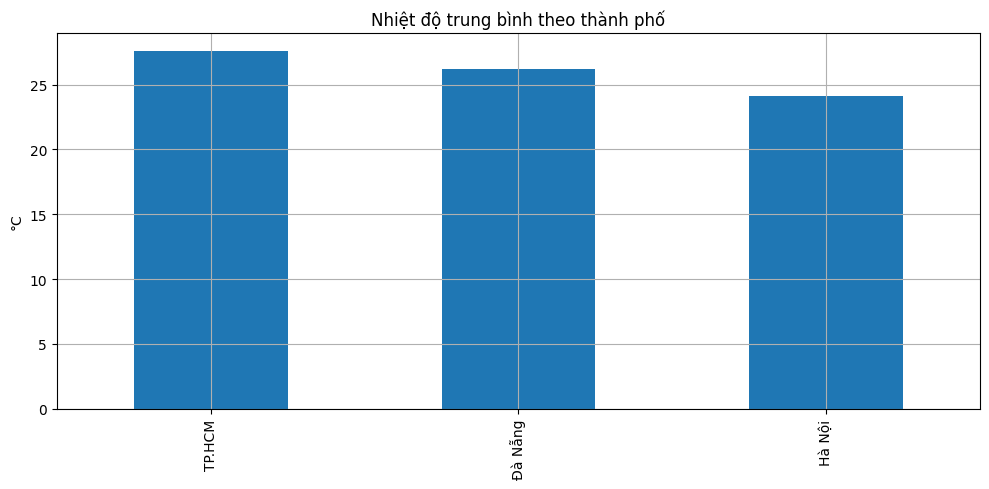

In [6]:
# Tính nhiệt độ trung bình, nhiệt độ cao nhất và số ngày nắng nóng.
q1 = (
    daily.groupby("city", as_index=False)
    .agg(
        nhiet_do_trung_binh=("temp_mean", "mean"),
        nhiet_do_cao_nhat=("temp_max", "max"),
        so_ngay_nang_nong=("hot_day", "sum"),
    )
    .sort_values("nhiet_do_trung_binh", ascending=False)
)

display(q1.round(2))
print(f"Kết luận: {q1.iloc[0]['city']} có nhiệt độ trung bình cao nhất.")

# Vẽ biểu đồ nhiệt độ trung bình theo thành phố.
ax = q1.plot.bar(x="city", y="nhiet_do_trung_binh", legend=False)
ax.set(title="Nhiệt độ trung bình theo thành phố", xlabel="", ylabel="°C")
plt.tight_layout()
plt.savefig(IMAGE_DIR / "01_nhiet_do_trung_binh_thanh_pho.png", dpi=150)
plt.show()

### Câu 2. Nhiệt độ thay đổi như thế nào theo từng tháng?

city,Hà Nội,TP.HCM,Đà Nẵng
month,,,
1,17.39,26.97,21.57
2,18.69,27.87,22.56
3,22.07,28.79,24.59
4,24.97,29.33,26.96
5,27.61,28.96,28.86
6,29.50,27.60,30.12
7,29.38,27.16,29.56
8,28.39,27.23,29.75
9,27.40,26.72,28.02


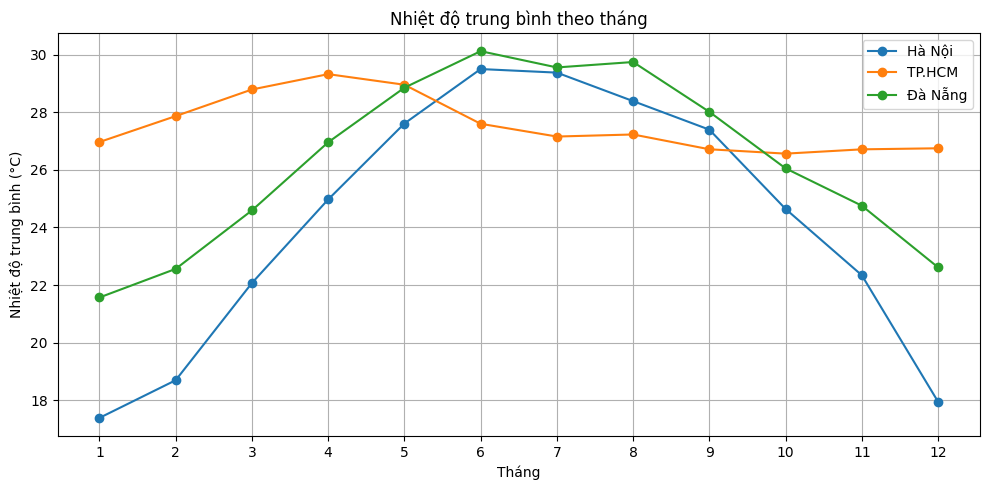

In [7]:
# Lấy nhiệt độ trung bình của từng tháng trong toàn bộ giai đoạn.
q2 = daily.groupby(["city", "month"], as_index=False)["temp_mean"].mean()
display(q2.pivot(index="month", columns="city", values="temp_mean").round(2))

# Vẽ đường biến động nhiệt độ theo tháng.
for city, group in q2.groupby("city"):
    plt.plot(group["month"], group["temp_mean"], marker="o", label=city)
plt.xticks(range(1, 13))
plt.xlabel("Tháng")
plt.ylabel("Nhiệt độ trung bình (°C)")
plt.title("Nhiệt độ trung bình theo tháng")
plt.legend()
plt.tight_layout()
plt.savefig(IMAGE_DIR / "02_nhiet_do_theo_thang.png", dpi=150)
plt.show()

### Câu 3. Khung giờ nào trong ngày thường có nhiệt độ cao nhất?

,Thành phố,Giờ nóng nhất,Nhiệt độ trung bình
14,Hà Nội,14,27.36
37,TP.HCM,13,31.72
60,Đà Nẵng,12,28.64


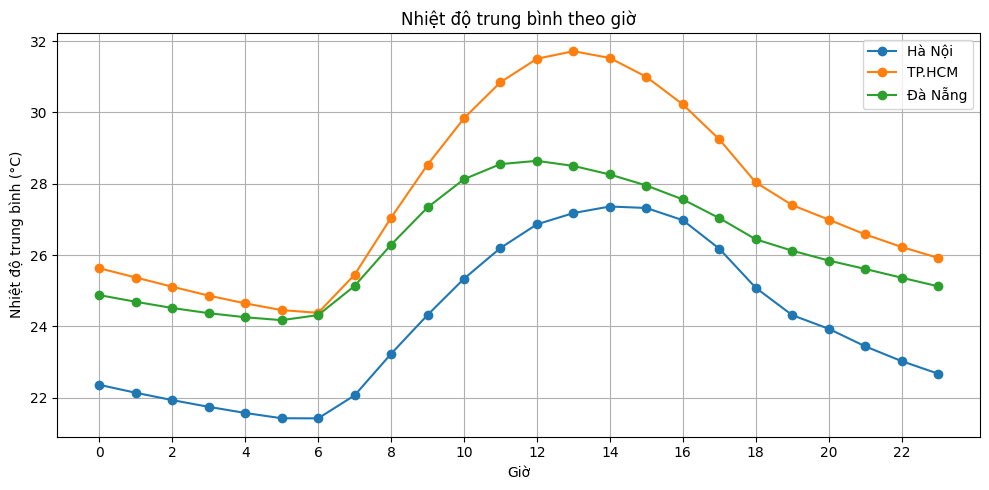

In [8]:
# Tính nhiệt độ trung bình tại từng giờ của mỗi thành phố.
q3 = hourly.groupby(["city", "hour"], as_index=False)["temperature"].mean()

# Tìm giờ có nhiệt độ trung bình cao nhất của từng thành phố.
hottest_hour = q3.loc[q3.groupby("city")["temperature"].idxmax()].copy()
hottest_hour = hottest_hour.rename(columns={
    "city": "Thành phố",
    "hour": "Giờ nóng nhất",
    "temperature": "Nhiệt độ trung bình"
})
display(hottest_hour.round(2))

# Vẽ biến động nhiệt độ trong 24 giờ.
for city, group in q3.groupby("city"):
    plt.plot(group["hour"], group["temperature"], marker="o", label=city)
plt.xticks(range(0, 24, 2))
plt.xlabel("Giờ")
plt.ylabel("Nhiệt độ trung bình (°C)")
plt.title("Nhiệt độ trung bình theo giờ")
plt.legend()
plt.tight_layout()
plt.savefig(IMAGE_DIR / "03_nhiet_do_theo_gio.png", dpi=150)
plt.show()

### Câu 4. Số ngày nắng nóng thay đổi như thế nào qua từng năm?

city,Hà Nội,TP.HCM,Đà Nẵng
year,,,
2020,35,66,6
2021,26,25,27
2022,11,30,12
2023,29,43,48
2024,23,86,68
2025,17,49,40
2026,13,55,23


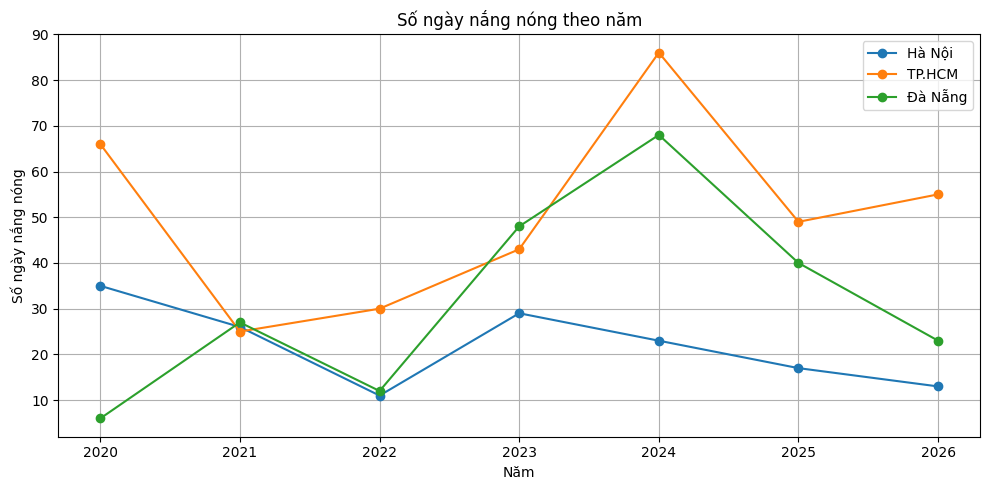

In [9]:
# Đếm số ngày nắng nóng theo thành phố và năm.
q4 = (
    daily.groupby(["city", "year"], as_index=False)["hot_day"]
    .sum()
    .rename(columns={"hot_day": "so_ngay_nang_nong"})
)

display(
    q4.pivot(index="year", columns="city", values="so_ngay_nang_nong")
    .fillna(0)
    .astype(int)
)

# Vẽ xu hướng số ngày nắng nóng theo năm.
for city, group in q4.groupby("city"):
    plt.plot(group["year"], group["so_ngay_nang_nong"], marker="o", label=city)
plt.xlabel("Năm")
plt.ylabel("Số ngày nắng nóng")
plt.title("Số ngày nắng nóng theo năm")
plt.legend()
plt.tight_layout()
plt.savefig(IMAGE_DIR / "04_so_ngay_nang_nong_theo_nam.png", dpi=150)
plt.show()

### Câu 5. Đợt nắng nóng kéo dài nhất tại mỗi thành phố

,city,bat_dau,ket_thuc,so_ngay
0,Hà Nội,2023-05-17,2023-05-22,6
1,TP.HCM,2024-03-24,2024-05-04,42
2,Đà Nẵng,2024-08-06,2024-08-23,18


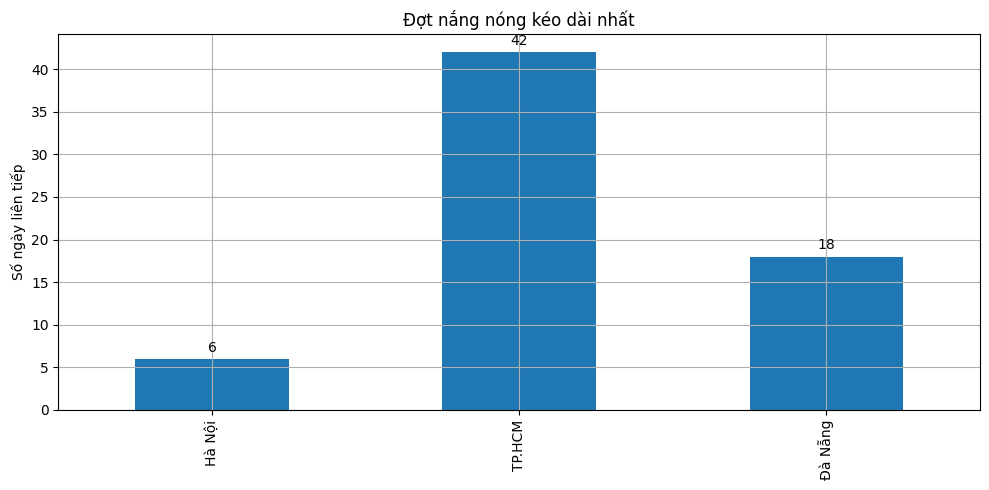

In [10]:
def longest_heatwave(city_df):
    """Tìm chuỗi ngày nắng nóng liên tiếp dài nhất của một thành phố."""
    x = city_df.sort_values("date").copy()

    # Khi trạng thái hot_day thay đổi, một nhóm liên tiếp mới được tạo.
    x["group_id"] = (x["hot_day"] != x["hot_day"].shift()).cumsum()
    hot = x[x["hot_day"] == 1].copy()

    if hot.empty:
        return {"bat_dau": pd.NaT, "ket_thuc": pd.NaT, "so_ngay": 0}

    # Tính ngày bắt đầu, kết thúc và độ dài của từng đợt nắng nóng.
    streaks = (
        hot.groupby("group_id")
        .agg(
            bat_dau=("date", "min"),
            ket_thuc=("date", "max"),
            so_ngay=("date", "size"),
        )
    )

    longest = streaks.loc[streaks["so_ngay"].idxmax()]
    return longest.to_dict()


# Tìm đợt nắng nóng dài nhất của từng thành phố.
rows = []
for city, group in daily.groupby("city"):
    result = longest_heatwave(group)
    rows.append({"city": city, **result})

q5 = pd.DataFrame(rows)
q5["so_ngay"] = q5["so_ngay"].astype(int)
display(q5)
q5.to_csv(DATA_DIR / "cac_dot_nang_nong.csv", index=False, encoding="utf-8-sig")

# Biểu đồ giúp so sánh độ dài đợt nắng nóng giữa ba thành phố.
ax = q5.plot.bar(x="city", y="so_ngay", legend=False)
ax.set(title="Đợt nắng nóng kéo dài nhất", xlabel="", ylabel="Số ngày liên tiếp")
ax.bar_label(ax.containers[0], padding=3)
plt.tight_layout()
plt.savefig(IMAGE_DIR / "05_dot_nang_nong_dai_nhat.png", dpi=150)
plt.show()

## 5. Chuẩn bị dữ liệu dự báo

Để tránh kết quả **0 ngày hoặc toàn bộ ngày trong tháng**, bài toán thứ hai không phân lớp từng ngày.  
Mô hình sẽ dự báo trực tiếp **số ngày nắng nóng của từng tháng**.

Các thuộc tính dùng cho dự báo đều biết trước thời điểm cần dự báo:
- Thành phố và tháng.
- Xu hướng thời gian.
- Kết quả của cùng tháng năm trước.
- Trung bình của cùng tháng trong 3 năm gần nhất.

**Kiểm thử:** tháng 7–12/2025.  
**Dự báo chính thức:** tháng 7–12/2026.

In [11]:
# Sắp xếp đúng thứ tự thời gian trước khi tạo thuộc tính trễ.
model_data = monthly.sort_values(["city", "date"]).copy()

# Chỉ số xu hướng thời gian tính theo số năm từ năm 2020.
model_data["trend"] = (
    model_data["year"] - model_data["year"].min()
    + (model_data["month"] - 1) / 12
)

# Giá trị của cùng tháng năm trước.
model_data["temp_lag12"] = model_data.groupby("city")["temp_mean_month"].shift(12)
model_data["hot_lag12"] = model_data.groupby("city")["hot_days_month"].shift(12)

# Trung bình của cùng tháng trong 3 năm trước, không sử dụng dữ liệu tương lai.
model_data["temp_same_month_3y"] = (
    model_data.groupby(["city", "month"])["temp_mean_month"]
    .transform(lambda s: s.shift(1).rolling(3, min_periods=1).mean())
)
model_data["hot_same_month_3y"] = (
    model_data.groupby(["city", "month"])["hot_days_month"]
    .transform(lambda s: s.shift(1).rolling(3, min_periods=1).mean())
)

# Tháng được coi là biến phân loại để mô hình học quy luật mùa vụ.
model_data["month_cat"] = model_data["month"].astype(str)

display(model_data.tail(12))

,city,year,month,temp_mean_month,hot_days_month,days_observed,date,days_in_month,trend,temp_lag12,hot_lag12,temp_same_month_3y,hot_same_month_3y,month_cat
219,Đà Nẵng,2025,6,29.481111,9,30,2025-06-01,30,5.416667,30.525972,18.0,30.234722,11.666667,6
220,Đà Nẵng,2025,7,29.747177,13,31,2025-07-01,31,5.500000,29.416129,8.0,29.374776,7.000000,7
221,Đà Nẵng,2025,8,29.534946,12,31,2025-08-01,31,5.583333,30.746371,23.0,30.015143,14.333333,8
222,Đà Nẵng,2025,9,27.575000,0,30,2025-09-01,30,5.666667,28.479722,5.0,28.110556,2.333333,9
223,Đà Nẵng,2025,10,26.182661,0,31,2025-10-01,31,5.750000,25.764919,0.0,25.959453,0.000000,10
224,Đà Nẵng,2025,11,24.101944,0,30,2025-11-01,30,5.833333,24.655833,0.0,24.982731,0.000000,11
225,Đà Nẵng,2025,12,23.084409,0,31,2025-12-01,31,5.916667,22.451747,0.0,22.678315,0.000000,12
226,Đà Nẵng,2026,1,21.338306,0,31,2026-01-01,31,6.000000,20.517742,0.0,21.343190,0.000000,1
227,Đà Nẵng,2026,2,23.296875,0,28,2026-02-01,28,6.083333,21.904018,0.0,22.761554,0.000000,2
228,Đà Nẵng,2026,3,24.421505,1,31,2026-03-01,31,6.166667,23.468414,0.0,24.213710,0.000000,3


## 6. Xây dựng và đánh giá mô hình

In [12]:
# Hai mô hình được so sánh; mô hình có MAE nhỏ nhất sẽ được chọn.
MODELS = {
    "Ridge": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        max_depth=6,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1,
    ),
}

CAT_COLS = ["city", "month_cat"]


def make_preprocessor(num_cols):
    """Tạo bộ tiền xử lý cho biến phân loại và biến số."""
    try:
        encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:  # Hỗ trợ phiên bản scikit-learn cũ.
        encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

    numeric_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

    return ColumnTransformer([
        ("cat", encoder, CAT_COLS),
        ("num", numeric_pipe, num_cols),
    ])


def evaluate_regression(target, num_cols, clip_count=False):
    """Huấn luyện trên quá khứ và đánh giá bằng tháng 7–12/2025."""
    train_mask = model_data["date"] < "2025-07-01"
    test_mask = (
        (model_data["date"] >= "2025-07-01")
        & (model_data["date"] <= "2025-12-01")
    )

    feature_cols = CAT_COLS + num_cols
    X_train = model_data.loc[train_mask, feature_cols]
    y_train = model_data.loc[train_mask, target]
    X_test = model_data.loc[test_mask, feature_cols]
    y_test = model_data.loc[test_mask, target]

    results = []
    fitted = {}

    for name, estimator in MODELS.items():
        pipeline = Pipeline([
            ("preprocess", make_preprocessor(num_cols)),
            ("model", clone(estimator)),
        ])
        pipeline.fit(X_train, y_train)
        pred = pipeline.predict(X_test)

        # Số ngày nắng nóng không thể nhỏ hơn 0 hoặc lớn hơn số ngày trong tháng.
        if clip_count:
            max_days = model_data.loc[test_mask, "days_in_month"].to_numpy()
            pred = np.clip(pred, 0, max_days)

        results.append({
            "Mô hình": name,
            "MAE": mean_absolute_error(y_test, pred),
            "RMSE": mean_squared_error(y_test, pred) ** 0.5,
            "R2": r2_score(y_test, pred),
        })
        fitted[name] = pipeline

    result_df = pd.DataFrame(results).sort_values("MAE").reset_index(drop=True)
    return result_df, fitted

### 6.1. Mô hình dự báo nhiệt độ trung bình tháng

In [13]:
# Thuộc tính dùng riêng cho dự báo nhiệt độ trung bình tháng.
TEMP_NUM_COLS = ["trend", "temp_lag12", "temp_same_month_3y"]

temp_eval, _ = evaluate_regression(
    target="temp_mean_month",
    num_cols=TEMP_NUM_COLS,
    clip_count=False,
)

display(temp_eval.round(3))
BEST_TEMP_MODEL = temp_eval.iloc[0]["Mô hình"]
print("Mô hình nhiệt độ được chọn:", BEST_TEMP_MODEL)

,Mô hình,MAE,RMSE,R2
0,Random Forest,0.847,1.330,0.754
1,Ridge,1.007,1.305,0.763


Mô hình nhiệt độ được chọn: Random Forest


### 6.2. Mô hình dự báo số ngày nắng nóng tháng

In [14]:
# Thuộc tính dùng cho dự báo số ngày nắng nóng tháng.
HOT_NUM_COLS = [
    "trend",
    "hot_lag12",
    "hot_same_month_3y",
    "temp_lag12",
    "temp_same_month_3y",
]

hot_eval, _ = evaluate_regression(
    target="hot_days_month",
    num_cols=HOT_NUM_COLS,
    clip_count=True,
)

display(hot_eval.round(3))
BEST_HOT_MODEL = hot_eval.iloc[0]["Mô hình"]
print("Mô hình số ngày nắng nóng được chọn:", BEST_HOT_MODEL)

,Mô hình,MAE,RMSE,R2
0,Random Forest,1.072,2.179,0.710
1,Ridge,1.429,2.046,0.745


Mô hình số ngày nắng nóng được chọn: Random Forest


## 7. Tạo dữ liệu đầu vào cho tháng 7–12/2026

In [15]:
def build_future_rows(history, start="2026-07-01", end="2026-12-01"):
    """Tạo thuộc tính cho các tháng tương lai chỉ từ dữ liệu quá khứ."""
    future_months = pd.date_range(start, end, freq="MS")
    rows = []

    for city in FILES.keys():
        city_history = history[history["city"] == city].copy()

        for future_date in future_months:
            month = future_date.month

            # Lấy dữ liệu của cùng tháng trong các năm trước.
            same_month = city_history[
                (city_history["month"] == month)
                & (city_history["date"] < future_date)
            ].sort_values("date")

            if same_month.empty:
                raise ValueError(f"Không đủ dữ liệu lịch sử cho {city}, tháng {month}")

            last_year = same_month.iloc[-1]
            recent_3_years = same_month.tail(3)

            rows.append({
                "city": city,
                "date": future_date,
                "year": future_date.year,
                "month": month,
                "month_cat": str(month),
                "days_in_month": future_date.days_in_month,
                "trend": (
                    future_date.year - history["year"].min()
                    + (month - 1) / 12
                ),
                "temp_lag12": last_year["temp_mean_month"],
                "hot_lag12": last_year["hot_days_month"],
                "temp_same_month_3y": recent_3_years["temp_mean_month"].mean(),
                "hot_same_month_3y": recent_3_years["hot_days_month"].mean(),
            })

    return pd.DataFrame(rows)


future = build_future_rows(monthly)
display(future.head(12))

,city,date,year,month,month_cat,days_in_month,trend,temp_lag12,hot_lag12,temp_same_month_3y,hot_same_month_3y
0,Hà Nội,2026-07-01,2026,7,7,31,6.500000,28.757661,5,29.227330,7.333333
1,Hà Nội,2026-08-01,2026,8,8,31,6.583333,28.225134,5,28.387142,2.333333
2,Hà Nội,2026-09-01,2026,9,9,30,6.666667,27.736806,0,27.446157,0.000000
3,Hà Nội,2026-10-01,2026,10,10,31,6.750000,25.301478,0,25.604749,0.000000
4,Hà Nội,2026-11-01,2026,11,11,30,6.833333,20.279583,0,22.162639,0.000000
5,Hà Nội,2026-12-01,2026,12,12,31,6.916667,20.073790,0,18.990054,0.000000
6,Đà Nẵng,2026-07-01,2026,7,7,31,6.500000,29.747177,13,29.710708,10.333333
7,Đà Nẵng,2026-08-01,2026,8,8,31,6.583333,29.534946,12,30.353226,18.333333
8,Đà Nẵng,2026-09-01,2026,9,9,30,6.666667,27.575000,0,28.112037,2.333333
9,Đà Nẵng,2026-10-01,2026,10,10,31,6.750000,26.182661,0,26.105959,0.000000


## 8. Huấn luyện lại và dự báo tháng 7–12/2026

In [16]:
def fit_final_model(model_name, target, num_cols):
    """Huấn luyện mô hình được chọn bằng toàn bộ dữ liệu hợp lệ."""
    feature_cols = CAT_COLS + num_cols
    pipeline = Pipeline([
        ("preprocess", make_preprocessor(num_cols)),
        ("model", clone(MODELS[model_name])),
    ])
    pipeline.fit(model_data[feature_cols], model_data[target])
    return pipeline


# Huấn luyện mô hình cuối cùng cho hai mục tiêu.
temp_model = fit_final_model(
    BEST_TEMP_MODEL,
    target="temp_mean_month",
    num_cols=TEMP_NUM_COLS,
)
hot_model = fit_final_model(
    BEST_HOT_MODEL,
    target="hot_days_month",
    num_cols=HOT_NUM_COLS,
)

# Dự báo nhiệt độ trung bình tháng.
future["nhiet_do_trung_binh_du_bao"] = temp_model.predict(
    future[CAT_COLS + TEMP_NUM_COLS]
)

# Dự báo trực tiếp số ngày nắng nóng trong tháng.
hot_pred = hot_model.predict(future[CAT_COLS + HOT_NUM_COLS])
hot_pred = np.clip(hot_pred, 0, future["days_in_month"])
future["so_ngay_nang_nong_du_bao"] = np.rint(hot_pred).astype(int)

# Chọn các cột kết quả chính.
forecast = future[[
    "city", "year", "month",
    "nhiet_do_trung_binh_du_bao",
    "so_ngay_nang_nong_du_bao",
]].copy()

forecast.to_csv(
    DATA_DIR / "ket_qua_du_bao_thang_7_12_2026.csv",
    index=False,
    encoding="utf-8-sig",
)

display(forecast.round(2))

,city,year,month,nhiet_do_trung_binh_du_bao,so_ngay_nang_nong_du_bao
0,Hà Nội,2026,7,29.36,10
1,Hà Nội,2026,8,28.71,4
2,Hà Nội,2026,9,27.37,1
3,Hà Nội,2026,10,25.63,0
4,Hà Nội,2026,11,22.33,0
5,Hà Nội,2026,12,18.65,0
6,Đà Nẵng,2026,7,29.57,10
7,Đà Nẵng,2026,8,29.92,15
8,Đà Nẵng,2026,9,28.05,3
9,Đà Nẵng,2026,10,26.25,1


### Câu dự báo 1. Nhiệt độ trung bình từng tháng

city,Hà Nội,TP.HCM,Đà Nẵng
month,,,
7,29.36,26.93,29.57
8,28.71,26.98,29.92
9,27.37,26.82,28.05
10,25.63,26.80,26.25
11,22.33,26.85,24.96
12,18.65,26.34,22.41


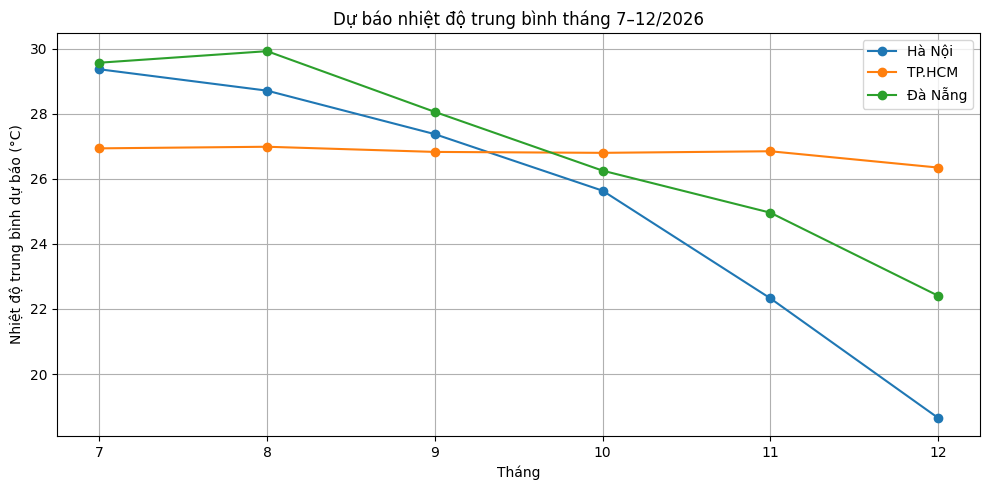

In [17]:
# Bảng kết quả nhiệt độ trung bình dự báo.
forecast_temp = forecast.pivot(
    index="month",
    columns="city",
    values="nhiet_do_trung_binh_du_bao",
)
display(forecast_temp.round(2))

# Vẽ biểu đồ dự báo nhiệt độ trung bình.
for city, group in forecast.groupby("city"):
    plt.plot(
        group["month"],
        group["nhiet_do_trung_binh_du_bao"],
        marker="o",
        label=city,
    )
plt.xticks(range(7, 13))
plt.xlabel("Tháng")
plt.ylabel("Nhiệt độ trung bình dự báo (°C)")
plt.title("Dự báo nhiệt độ trung bình tháng 7–12/2026")
plt.legend()
plt.tight_layout()
plt.savefig(IMAGE_DIR / "06_du_bao_nhiet_do_2026.png", dpi=150)
plt.show()

### Câu dự báo 2. Số ngày nắng nóng từng tháng

city,Hà Nội,TP.HCM,Đà Nẵng
month,,,
7,10,1,10
8,4,1,15
9,1,0,3
10,0,0,1
11,0,0,1
12,0,1,1


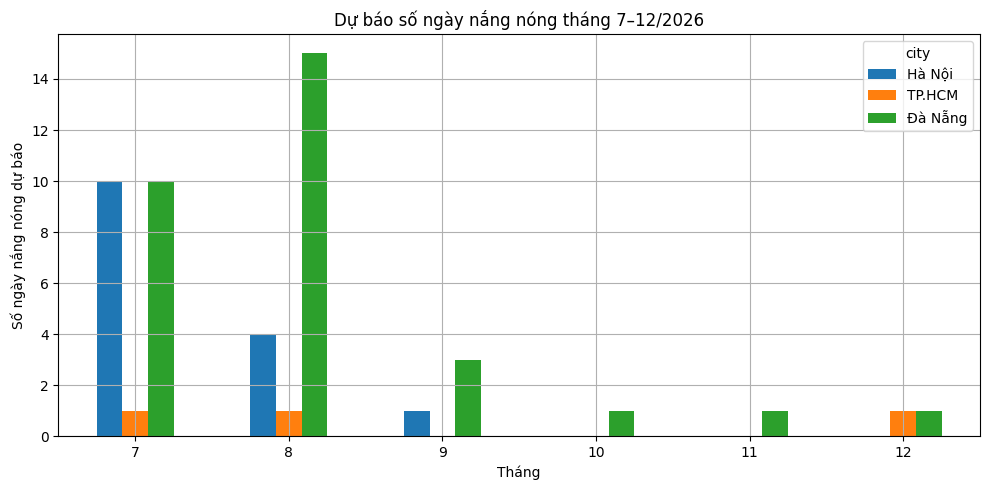

In [18]:
# Bảng kết quả số ngày nắng nóng dự báo.
forecast_hot = forecast.pivot(
    index="month",
    columns="city",
    values="so_ngay_nang_nong_du_bao",
)
display(forecast_hot.astype(int))

# Vẽ biểu đồ số ngày nắng nóng dự báo.
forecast_hot.plot.bar()
plt.xlabel("Tháng")
plt.ylabel("Số ngày nắng nóng dự báo")
plt.title("Dự báo số ngày nắng nóng tháng 7–12/2026")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(IMAGE_DIR / "07_du_bao_ngay_nang_nong_2026.png", dpi=150)
plt.show()